# Pneumonia Chest X-ray Classification using Deep Learning

## Project Overview

This project aims to develop a robust deep learning system capable of automatically detecting Pneumonia from chest X-ray images. Multiple transfer learning architectures are explored and compared to identify the best-performing model.

## Objectives

- Perform detailed Exploratory Data Analysis (EDA)
- Apply image preprocessing and augmentation
- Train multiple deep learning models
- Compare model performance using multiple evaluation metrics
- Generate explainable predictions using Grad-CAM
- Deploy the best model using Streamlit

---

In [1]:
import os
import random
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score
)

from tqdm import tqdm
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow Version :", tf.__version__)
print("NumPy Version      :", np.__version__)
print("GPU Available      :", tf.config.list_physical_devices('GPU'))

TensorFlow Version : 2.21.0
NumPy Version      : 2.2.6
GPU Available      : []


In [2]:
BASE_DIR = "../data/chest_xray"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")
TEST_DIR = os.path.join(BASE_DIR, "test")

print("Train Path :", TRAIN_DIR)
print("Validation Path :", VAL_DIR)
print("Test Path :", TEST_DIR)

for folder in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    print("\n", folder)
    print(os.listdir(folder))

Train Path : ../data/chest_xray\train
Validation Path : ../data/chest_xray\val
Test Path : ../data/chest_xray\test

 ../data/chest_xray\train
['.DS_Store', 'NORMAL', 'PNEUMONIA']

 ../data/chest_xray\val
['.DS_Store', 'NORMAL', 'PNEUMONIA']

 ../data/chest_xray\test
['.DS_Store', 'NORMAL', 'PNEUMONIA']


# Exploratory Data Analysis

This section explores the dataset by creating a structured dataframe, analyzing class distribution, and examining image properties before training any deep learning model.

In [3]:
train_images = []
val_images = []
test_images = []

for dataset, folder in [("Train", TRAIN_DIR), ("Validation", VAL_DIR), ("Test", TEST_DIR)]:
    for label in sorted(os.listdir(folder)):
        label_path = os.path.join(folder, label)

        if not os.path.isdir(label_path):
            continue

        for image in sorted(os.listdir(label_path)):
            image_path = os.path.join(label_path, image)

            if not os.path.isfile(image_path):
                continue

            if image.lower().endswith((".jpg", ".jpeg", ".png")):
                row = [dataset, label, image_path]

                if dataset == "Train":
                    train_images.append(row)
                elif dataset == "Validation":
                    val_images.append(row)
                else:
                    test_images.append(row)

df = pd.DataFrame(
    train_images + val_images + test_images,
    columns=["Dataset", "Label", "Path"]
)

df.head()

,Dataset,Label,Path
0,Train,NORMAL,../data/chest_xray\train\NORMAL\IM-0115-0001.jpeg
1,Train,NORMAL,../data/chest_xray\train\NORMAL\IM-0117-0001.jpeg
2,Train,NORMAL,../data/chest_xray\train\NORMAL\IM-0119-0001.jpeg
3,Train,NORMAL,../data/chest_xray\train\NORMAL\IM-0122-0001.jpeg
4,Train,NORMAL,../data/chest_xray\train\NORMAL\IM-0125-0001.jpeg


In [4]:
display(df.sample(10))

print(f"Total Images      : {len(df)}")
print(f"Training Images   : {len(train_images)}")
print(f"Validation Images : {len(val_images)}")
print(f"Testing Images    : {len(test_images)}")

print("\nDataset Distribution")

display(
    df.groupby(["Dataset", "Label"])
      .size()
      .reset_index(name="Count")
)

,Dataset,Label,Path
3649,Train,PNEUMONIA,../data/chest_xray\train\PNEUMONIA\person398_b...
4211,Train,PNEUMONIA,../data/chest_xray\train\PNEUMONIA\person539_v...
960,Train,NORMAL,../data/chest_xray\train\NORMAL\NORMAL2-IM-090...
23,Train,NORMAL,../data/chest_xray\train\NORMAL\IM-0160-0001.jpeg
810,Train,NORMAL,../data/chest_xray\train\NORMAL\NORMAL2-IM-066...
1670,Train,PNEUMONIA,../data/chest_xray\train\PNEUMONIA\person1176_...
1176,Train,NORMAL,../data/chest_xray\train\NORMAL\NORMAL2-IM-117...
2579,Train,PNEUMONIA,../data/chest_xray\train\PNEUMONIA\person1574_...
4333,Train,PNEUMONIA,../data/chest_xray\train\PNEUMONIA\person56_ba...
1897,Train,PNEUMONIA,../data/chest_xray\train\PNEUMONIA\person1288_...


Total Images      : 5856
Training Images   : 5216
Validation Images : 16
Testing Images    : 624

Dataset Distribution


,Dataset,Label,Count
0,Test,NORMAL,234
1,Test,PNEUMONIA,390
2,Train,NORMAL,1341
3,Train,PNEUMONIA,3875
4,Validation,NORMAL,8
5,Validation,PNEUMONIA,8


# Class Distribution Analysis

This section examines the balance between Normal and Pneumonia images across the dataset to identify any class imbalance before model training.

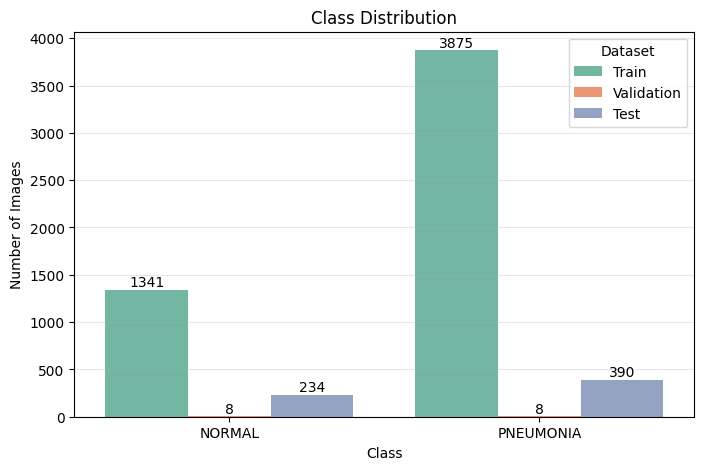

In [5]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Label",
    hue="Dataset",
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.grid(axis="y", alpha=0.3)

plt.show()

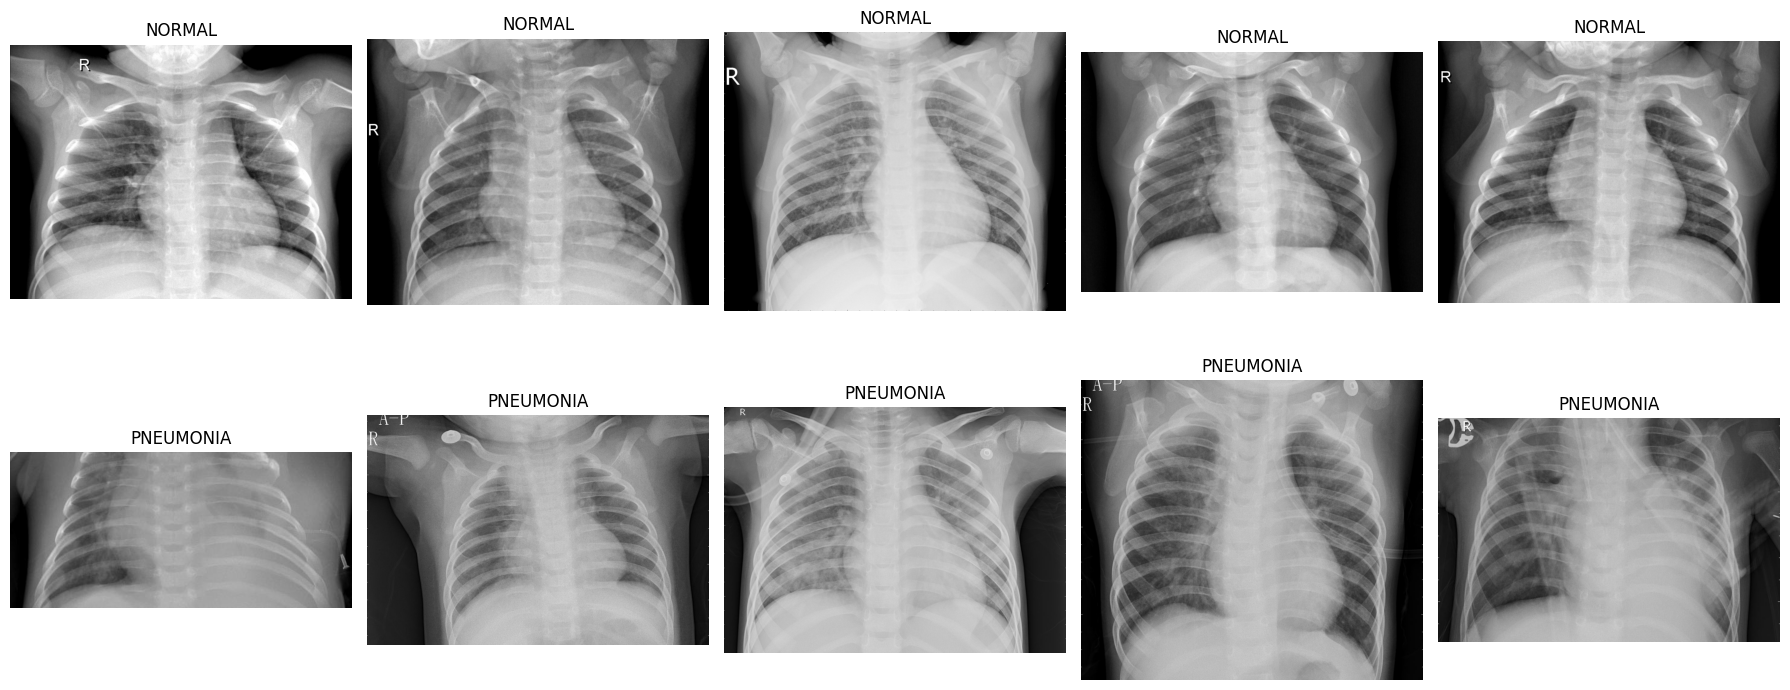

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

classes = sorted(df["Label"].unique())

for row, label in enumerate(classes):
    samples = df[df["Label"] == label].sample(5, random_state=42)

    for col, (_, sample) in enumerate(samples.iterrows()):
        image = cv2.imread(sample["Path"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        axes[row, col].imshow(image)
        axes[row, col].set_title(label)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

# Image Metadata Extraction

Image properties such as dimensions, aspect ratio, file size, brightness, contrast, and pixel statistics are extracted for further analysis.

In [7]:
image_stats = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    image = cv2.imread(row["Path"], cv2.IMREAD_GRAYSCALE)

    height, width = image.shape

    image_stats.append({
        "Dataset": row["Dataset"],
        "Label": row["Label"],
        "Path": row["Path"],
        "Width": width,
        "Height": height,
        "Aspect_Ratio": round(width / height, 3),
        "File_Size_KB": round(os.path.getsize(row["Path"]) / 1024, 2),
        "Mean_Intensity": image.mean(),
        "Std_Intensity": image.std(),
        "Min_Pixel": image.min(),
        "Max_Pixel": image.max(),
        "Brightness": image.mean(),
        "Contrast": image.std()
    })

image_stats = pd.DataFrame(image_stats)

image_stats.head()

100%|██████████████████████████████████████████████████████████████████████████████| 5856/5856 [03:59<00:00, 24.46it/s]


,Dataset,Label,Path,Width,Height,Aspect_Ratio,File_Size_KB,Mean_Intensity,Std_Intensity,Min_Pixel,Max_Pixel,Brightness,Contrast
0,Train,NORMAL,../data/chest_xray\train\NORMAL\IM-0115-0001.jpeg,2090,1858,1.125,850.38,128.907478,62.301030,0,255,128.907478,62.301030
1,Train,NORMAL,../data/chest_xray\train\NORMAL\IM-0117-0001.jpeg,1422,1152,1.234,396.78,100.650624,59.808347,0,255,100.650624,59.808347
2,Train,NORMAL,../data/chest_xray\train\NORMAL\IM-0119-0001.jpeg,1810,1434,1.262,568.98,121.971530,68.856428,0,255,121.971530,68.856428
3,Train,NORMAL,../data/chest_xray\train\NORMAL\IM-0122-0001.jpeg,1618,1279,1.265,460.50,132.986188,64.970663,0,255,132.986188,64.970663
4,Train,NORMAL,../data/chest_xray\train\NORMAL\IM-0125-0001.jpeg,1600,1125,1.422,440.71,106.224797,65.088725,0,255,106.224797,65.088725


In [8]:
display(image_stats.describe().T)

print(f"Duplicate Rows : {image_stats.duplicated().sum()}")

print(f"\nMissing Values\n")

display(image_stats.isnull().sum())

,count,mean,std,min,25%,50%,75%,max
Width,5856.0,1327.880806,363.500922,384.000000,1056.000000,1281.000000,1560.000000,2916.000000
Height,5856.0,970.689037,383.392117,127.000000,688.000000,888.000000,1187.000000,2713.000000
Aspect_Ratio,5856.0,1.442986,0.254354,0.835000,1.261750,1.416000,1.586000,3.379000
File_Size_KB,5856.0,206.199255,258.600342,5.310000,54.750000,93.590000,230.487500,2357.760000
Mean_Intensity,5856.0,122.786271,18.391648,58.722966,111.616378,122.753346,134.313617,221.536623
Std_Intensity,5856.0,56.989903,9.396742,20.415354,50.736895,57.328348,63.696503,87.480423
Min_Pixel,5856.0,0.212090,2.775167,0.000000,0.000000,0.000000,0.000000,76.000000
Max_Pixel,5856.0,252.759563,10.627402,153.000000,255.000000,255.000000,255.000000,255.000000
Brightness,5856.0,122.786271,18.391648,58.722966,111.616378,122.753346,134.313617,221.536623
Contrast,5856.0,56.989903,9.396742,20.415354,50.736895,57.328348,63.696503,87.480423


Duplicate Rows : 0

Missing Values



Dataset           0
Label             0
Path              0
Width             0
Height            0
Aspect_Ratio      0
File_Size_KB      0
Mean_Intensity    0
Std_Intensity     0
Min_Pixel         0
Max_Pixel         0
Brightness        0
Contrast          0
dtype: int64

# Distribution of Image Characteristics

The distributions of image dimensions, file sizes, brightness, and contrast are analyzed to understand dataset variability and identify preprocessing requirements.

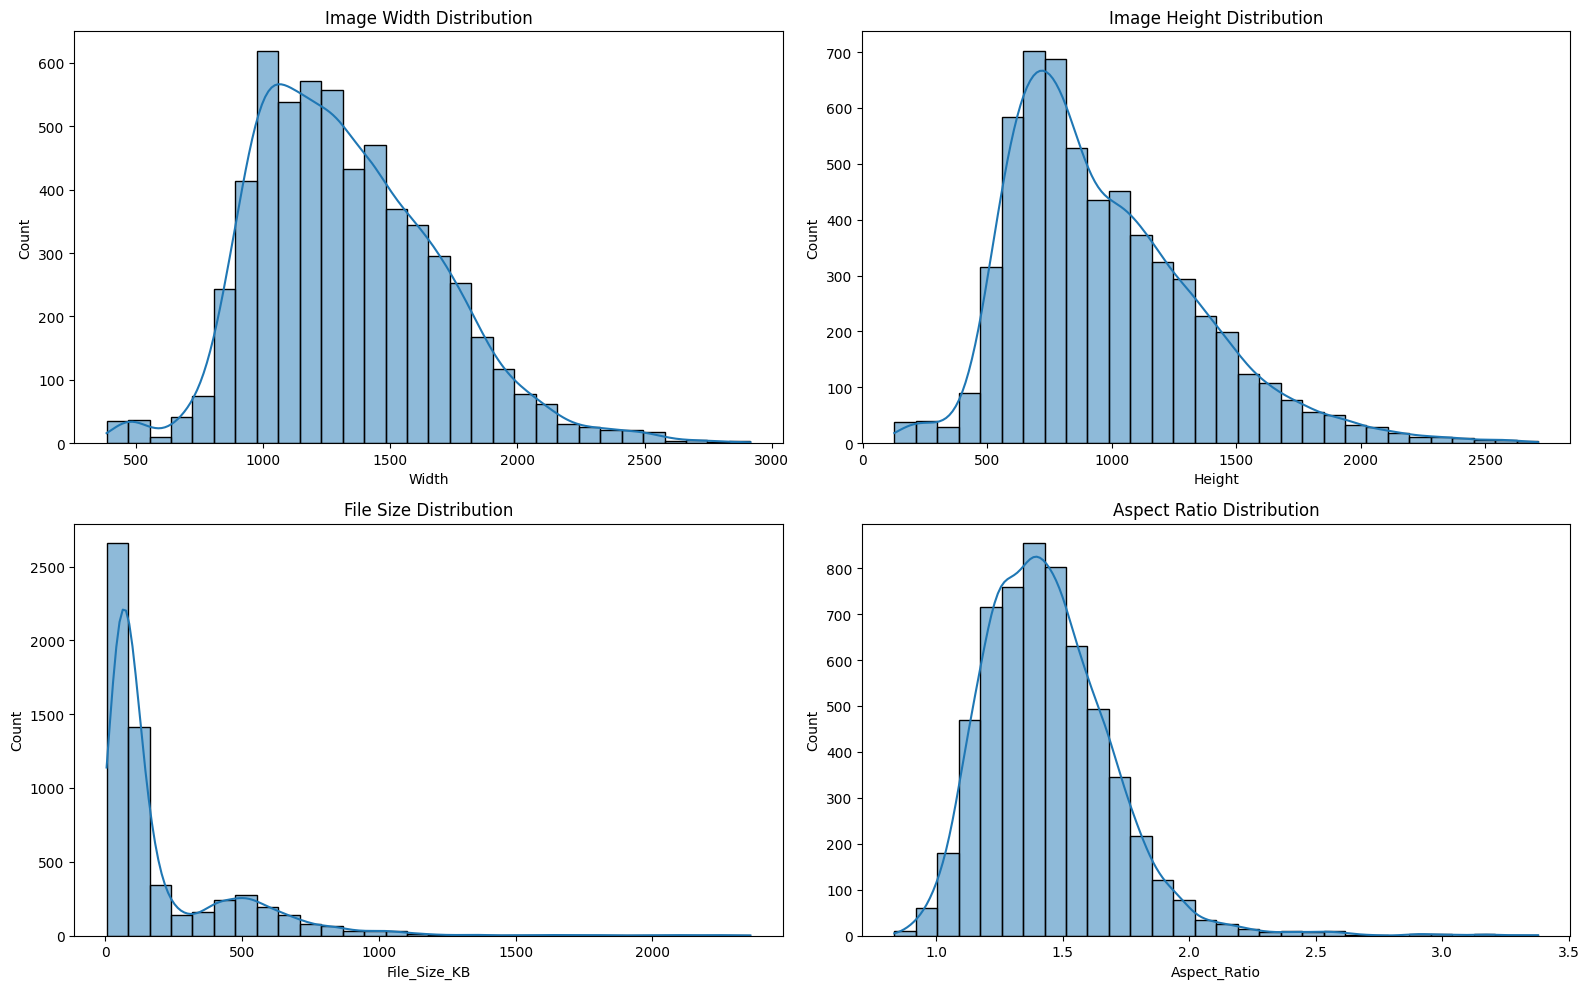

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(image_stats["Width"], bins=30, kde=True, ax=axes[0,0])
axes[0,0].set_title("Image Width Distribution")

sns.histplot(image_stats["Height"], bins=30, kde=True, ax=axes[0,1])
axes[0,1].set_title("Image Height Distribution")

sns.histplot(image_stats["File_Size_KB"], bins=30, kde=True, ax=axes[1,0])
axes[1,0].set_title("File Size Distribution")

sns.histplot(image_stats["Aspect_Ratio"], bins=30, kde=True, ax=axes[1,1])
axes[1,1].set_title("Aspect Ratio Distribution")

plt.tight_layout()
plt.show()

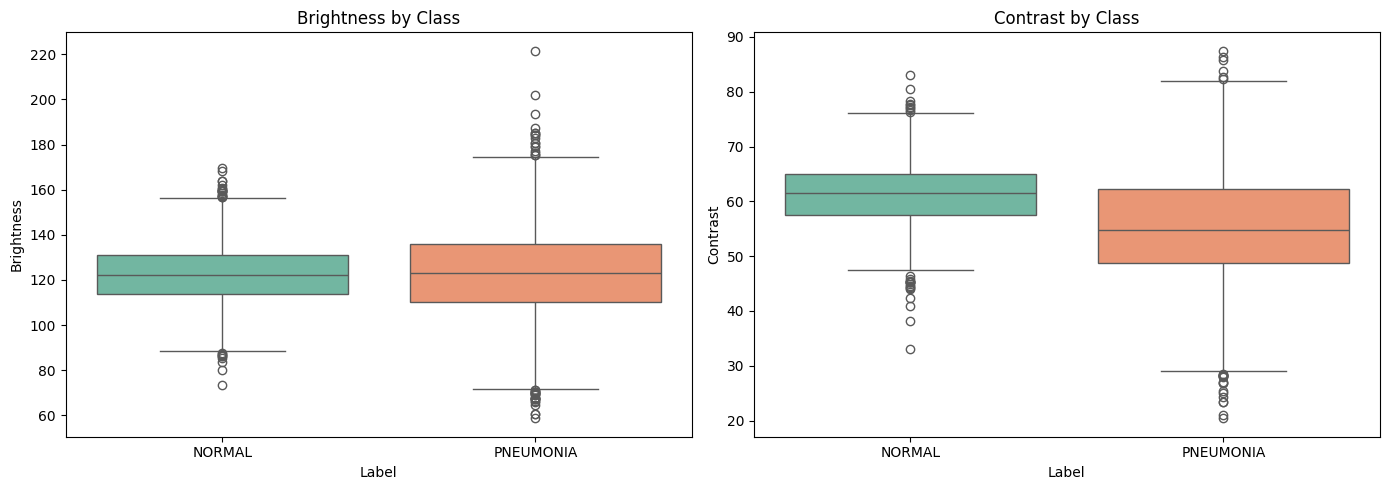

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(
    data=image_stats,
    x="Label",
    y="Brightness",
    palette="Set2",
    ax=axes[0]
)

axes[0].set_title("Brightness by Class")

sns.boxplot(
    data=image_stats,
    x="Label",
    y="Contrast",
    palette="Set2",
    ax=axes[1]
)

axes[1].set_title("Contrast by Class")

plt.tight_layout()
plt.show()

# Image Quality Analysis

Image quality is evaluated using blur detection and entropy analysis. Blur estimation helps identify low-quality images, while entropy measures the amount of information present in each image.

In [11]:
laplacian_variance = []
entropy_values = []

for path in tqdm(df["Path"]):
    image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    blur = cv2.Laplacian(image, cv2.CV_64F).var()

    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    hist = hist / hist.sum()

    entropy = -np.sum(hist * np.log2(hist + 1e-10))

    laplacian_variance.append(blur)
    entropy_values.append(entropy)

image_stats["Blur_Score"] = laplacian_variance
image_stats["Entropy"] = entropy_values

image_stats.head()

100%|██████████████████████████████████████████████████████████████████████████████| 5856/5856 [03:36<00:00, 27.07it/s]


,Dataset,Label,Path,Width,Height,Aspect_Ratio,File_Size_KB,Mean_Intensity,Std_Intensity,Min_Pixel,Max_Pixel,Brightness,Contrast,Blur_Score,Entropy
0,Train,NORMAL,../data/chest_xray\train\NORMAL\IM-0115-0001.jpeg,2090,1858,1.125,850.38,128.907478,62.301030,0,255,128.907478,62.301030,72.224400,7.676016
1,Train,NORMAL,../data/chest_xray\train\NORMAL\IM-0117-0001.jpeg,1422,1152,1.234,396.78,100.650624,59.808347,0,255,100.650624,59.808347,97.994290,7.530555
2,Train,NORMAL,../data/chest_xray\train\NORMAL\IM-0119-0001.jpeg,1810,1434,1.262,568.98,121.971530,68.856428,0,255,121.971530,68.856428,90.731133,7.303908
3,Train,NORMAL,../data/chest_xray\train\NORMAL\IM-0122-0001.jpeg,1618,1279,1.265,460.50,132.986188,64.970663,0,255,132.986188,64.970663,80.234756,7.573775
4,Train,NORMAL,../data/chest_xray\train\NORMAL\IM-0125-0001.jpeg,1600,1125,1.422,440.71,106.224797,65.088725,0,255,106.224797,65.088725,112.328822,7.331294


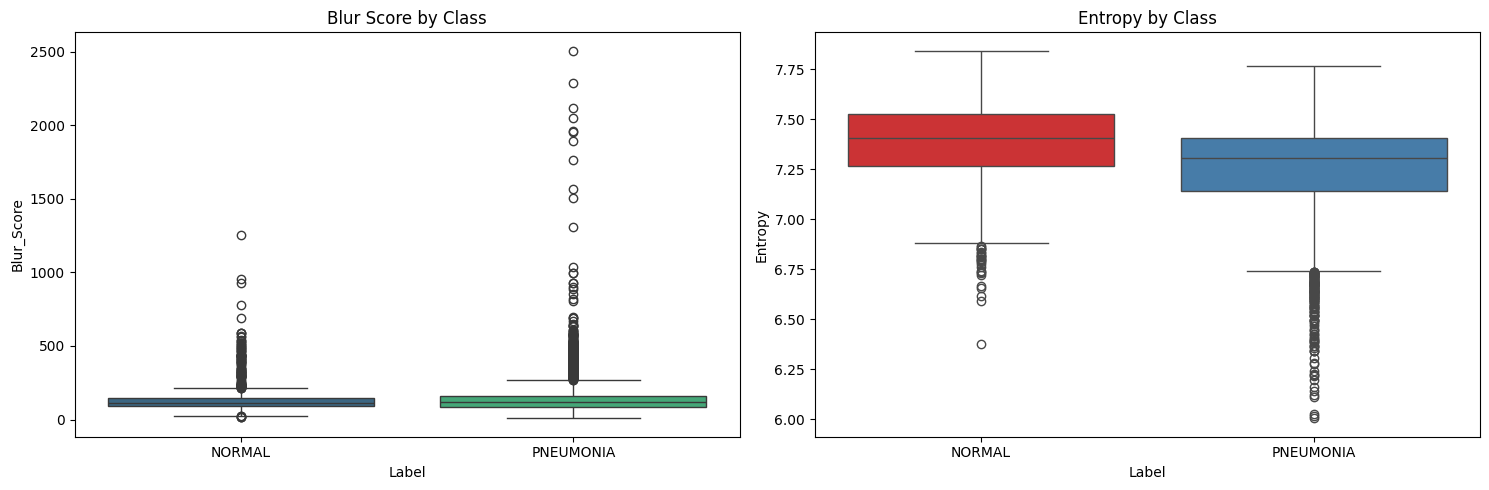

,count,mean,std,min,25%,50%,75%,max
Blur_Score,5856.0,143.627935,125.405722,8.124156,90.428048,118.131342,155.329269,2505.983038
Entropy,5856.0,7.285662,0.228024,6.004755,7.176886,7.328520,7.439839,7.841582


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))

sns.boxplot(
    data=image_stats,
    x="Label",
    y="Blur_Score",
    palette="viridis",
    ax=axes[0]
)

axes[0].set_title("Blur Score by Class")

sns.boxplot(
    data=image_stats,
    x="Label",
    y="Entropy",
    palette="Set1",
    ax=axes[1]
)

axes[1].set_title("Entropy by Class")

plt.tight_layout()
plt.show()

display(
    image_stats[["Blur_Score","Entropy"]].describe().T
)

In [13]:
import hashlib

hashes = []
corrupted = []

for path in tqdm(df["Path"]):
    try:
        with open(path, "rb") as f:
            hashes.append(hashlib.md5(f.read()).hexdigest())
        corrupted.append(False)
    except:
        hashes.append(None)
        corrupted.append(True)

image_stats["Hash"] = hashes
image_stats["Corrupted"] = corrupted

duplicate_images = image_stats["Hash"].duplicated().sum()

print(f"Corrupted Images : {image_stats['Corrupted'].sum()}")
print(f"Duplicate Images : {duplicate_images}")

100%|████████████████████████████████████████████████████████████████████████████| 5856/5856 [00:05<00:00, 1111.49it/s]


Corrupted Images : 0
Duplicate Images : 32


In [14]:
quality_report = pd.DataFrame({
    "Metric": [
        "Total Images",
        "Corrupted Images",
        "Duplicate Images",
        "Very Dark Images",
        "Very Bright Images",
        "Very Blurry Images"
    ],
    "Count": [
        len(image_stats),
        image_stats["Corrupted"].sum(),
        duplicate_images,
        (image_stats["Brightness"] < 60).sum(),
        (image_stats["Brightness"] > 190).sum(),
        (image_stats["Blur_Score"] < 100).sum()
    ]
})

display(quality_report)

,Metric,Count
0,Total Images,5856
1,Corrupted Images,0
2,Duplicate Images,32
3,Very Dark Images,1
4,Very Bright Images,3
5,Very Blurry Images,1935


# Image Preprocessing

The images are resized, enhanced using CLAHE, normalized, and converted into TensorFlow datasets for efficient model training.

In [15]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_df = df[df["Dataset"] == "Train"].reset_index(drop=True)
test_df = df[df["Dataset"] == "Test"].reset_index(drop=True)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["Label"],
    random_state=SEED
)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(4172, 3)
(1044, 3)
(624, 3)


**Test set isolation:** `test_df` is only ever passed through `evaluate_model()`
for reporting metrics. It is never used for training, validation, early stopping,
or hyperparameter/threshold selection — those all draw exclusively from
`train_df`/`val_df`. This keeps the final test metrics an honest estimate of
generalization, not a number that's been indirectly tuned against.

In [16]:
label_map = {
    "NORMAL": 0,
    "PNEUMONIA": 1
}

train_df["Target"] = train_df["Label"].map(label_map)
val_df["Target"] = val_df["Label"].map(label_map)
test_df["Target"] = test_df["Label"].map(label_map)

display(train_df.head())

print(label_map)

,Dataset,Label,Path,Target
99,Train,NORMAL,../data/chest_xray\train\NORMAL\IM-0273-0001.jpeg,0
1284,Train,NORMAL,../data/chest_xray\train\NORMAL\NORMAL2-IM-130...,0
5142,Train,PNEUMONIA,../data/chest_xray\train\PNEUMONIA\person963_v...,1
1365,Train,PNEUMONIA,../data/chest_xray\train\PNEUMONIA\person1016_...,1
2649,Train,PNEUMONIA,../data/chest_xray\train\PNEUMONIA\person1604_...,1


{'NORMAL': 0, 'PNEUMONIA': 1}


In [17]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["Target"]),
    y=train_df["Target"]
)

class_weight_dict = dict(enumerate(class_weights))

print("Class weights:", class_weight_dict)


Class weights: {0: np.float64(1.9440820130475303), 1: np.float64(0.6731203614069055)}


**Why class weights instead of oversampling/undersampling:** oversampling the
minority class (NORMAL) risks the model memorizing duplicated samples, and
undersampling PNEUMONIA throws away real training data. `class_weight="balanced"`
instead re-weights the loss function itself so misclassifying the minority class is
penalized more heavily, without altering the underlying data distribution seen
during training.

In [18]:
def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])

    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    return image, label


In [19]:
train_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            train_df["Path"].values,
            train_df["Target"].values.astype(np.int32)
        )
    )
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(len(train_df), seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            val_df["Path"].values,
            val_df["Target"].values.astype(np.int32)
        )
    )
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            test_df["Path"].values,
            test_df["Target"].values.astype(np.int32)
        )
    )
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

(32, 224, 224, 3)
(32,)


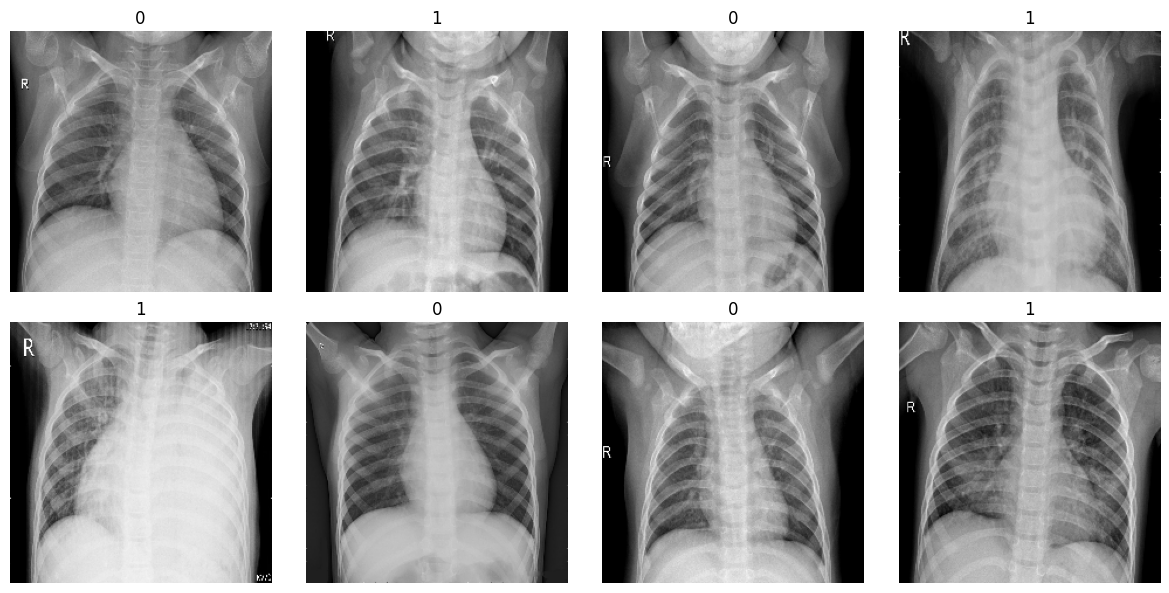

In [20]:
images, labels = next(iter(train_dataset))

print(images.shape)
print(labels.shape)

plt.figure(figsize=(12,6))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(tf.cast(images[i], tf.uint8))
    plt.title(labels[i].numpy())
    plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.10)
])

In [22]:
from tensorflow.keras.applications import (
    MobileNetV2,
    DenseNet121,
    EfficientNetB0
)

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

In [23]:
MODELS = {
    "MobileNetV2": {
        "backbone": MobileNetV2,
        "preprocess": mobilenet_preprocess
    },
    "DenseNet121": {
        "backbone": DenseNet121,
        "preprocess": densenet_preprocess
    },
    "EfficientNetB0": {
        "backbone": EfficientNetB0,
        "preprocess": efficientnet_preprocess
    }
}

In [24]:
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam

In [25]:
def build_model(model_name):

    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    backbone = None

    if model_name == "CNN":

        x = layers.Rescaling(1./255)(inputs)

        x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)

        x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)

        x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)

        x = layers.Conv2D(256, 3, activation="relu", padding="same")(x)

        x = GlobalAveragePooling2D()(x)

    else:

        x = data_augmentation(inputs)

        x = MODELS[model_name]["preprocess"](x)

        backbone = MODELS[model_name]["backbone"](
            include_top=False,
            weights="imagenet",
            input_tensor=x
        )

        backbone.trainable = False

        x = GlobalAveragePooling2D()(backbone.output)

    x = BatchNormalization()(x)

    x = Dense(512, activation="relu")(x)

    x = Dropout(0.5)(x)

    x = Dense(128, activation="relu")(x)

    x = Dropout(0.3)(x)

    outputs = Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )

    return model, backbone


In [26]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

In [27]:
def train_model(model, model_name, class_weight=None):

    checkpoint = ModelCheckpoint(
        f"../models/{model_name}.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )

    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=20,
        class_weight=class_weight,
        callbacks=[
            early_stopping,
            reduce_lr,
            checkpoint
        ],
        verbose=1
    )

    return history


In [28]:
cnn_model, _ = build_model("CNN")

cnn_history = train_model(
    cnn_model,
    "CNN",
    class_weight=class_weight_dict
)


Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8377 - auc: 0.9002 - loss: 0.3964 - precision: 0.9423 - recall: 0.8308
Epoch 1: val_accuracy improved from None to 0.74330, saving model to ../models/CNN.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 302s 2s/step - accuracy: 0.8742 - auc: 0.9416 - loss: 0.3094 - precision: 0.9653 - recall: 0.8616 - val_accuracy: 0.7433 - val_auc: 0.6482 - val_loss: 0.9105 - val_precision: 0.7433 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9181 - auc: 0.9712 - loss: 0.2128 - precision: 0.9769 - recall: 0.9103
Epoch 2: val_accuracy did not improve from 0.74330
131/131 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.9202 - auc: 0.9729 - loss: 0.2060 - precision: 0.9766 - recall: 0.9145 - val_accuracy: 0.7433 - val_auc: 0.5000 - val_loss: 2.1675 - val_precision: 0.7433 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.924

In [29]:
cnn_results = cnn_model.evaluate(
    test_dataset,
    verbose=0,
    return_dict=True
)

pd.DataFrame(cnn_results, index=["CNN"]).T

,CNN
accuracy,0.754808
auc,0.909402
loss,0.782295
precision,0.719852
recall,0.994872


In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [31]:
def evaluate_model(model, dataset):

    y_true = []
    y_prob = []

    for images, labels in dataset:

        predictions = model.predict(images, verbose=0).flatten()

        y_true.extend(labels.numpy())
        y_prob.extend(predictions)

    y_true = np.array(y_true)

    y_prob = np.array(y_prob)

    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob)
    }

    return metrics, y_true, y_pred, y_prob

In [32]:
cnn_metrics, y_true, y_pred, y_prob = evaluate_model(
    cnn_model,
    test_dataset
)

pd.DataFrame(cnn_metrics, index=["CNN"]).T

,CNN
Accuracy,0.754808
Precision,0.719852
Recall,0.994872
F1 Score,0.835307
AUC,0.924085


# Training Visualization

Training and validation curves are visualized to monitor convergence and detect overfitting or underfitting.

In [33]:
def plot_history(history, title):

    history = history.history

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history["accuracy"], label="Train")
    axes[0].plot(history["val_accuracy"], label="Validation")
    axes[0].set_title(f"{title} Accuracy")
    axes[0].legend()

    axes[1].plot(history["loss"], label="Train")
    axes[1].plot(history["val_loss"], label="Validation")
    axes[1].set_title(f"{title} Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

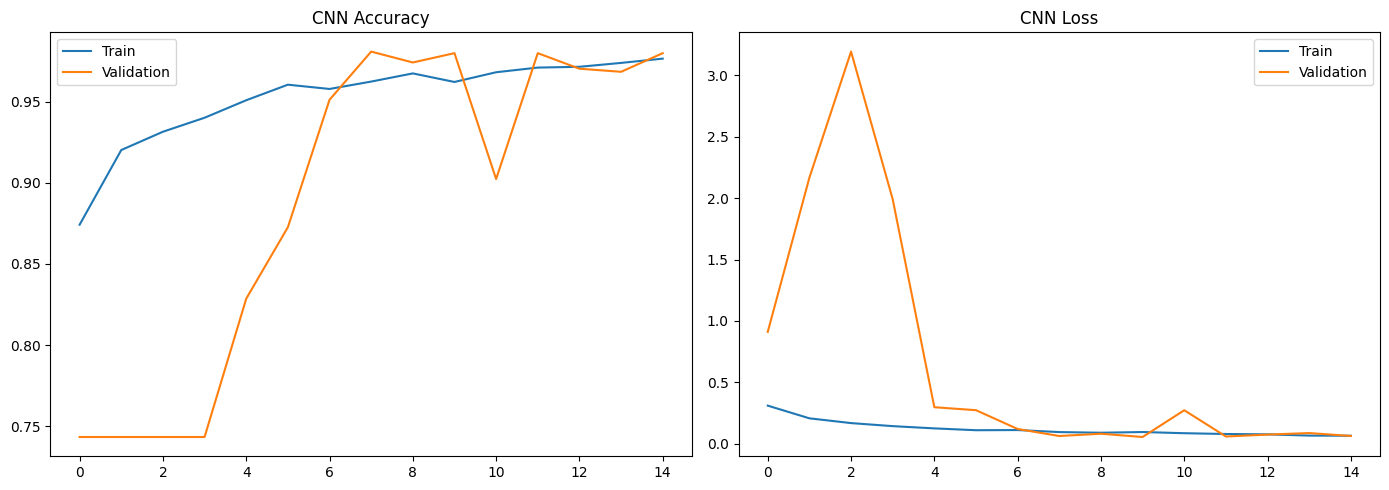

In [34]:
plot_history(
    cnn_history,
    "CNN"
)

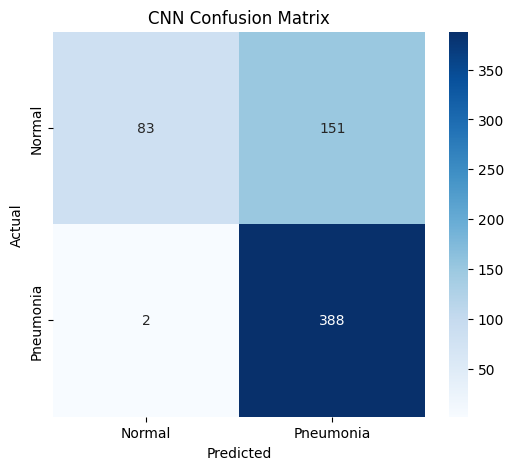

              precision    recall  f1-score   support

           0       0.98      0.35      0.52       234
           1       0.72      0.99      0.84       390

    accuracy                           0.75       624
   macro avg       0.85      0.67      0.68       624
weighted avg       0.82      0.75      0.72       624



In [35]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Pneumonia"],
    yticklabels=["Normal","Pneumonia"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")

plt.show()

print(classification_report(y_true, y_pred))

# MobileNetV2 - Feature Extraction

A pretrained MobileNetV2 model is used as a fixed feature extractor by freezing the convolutional backbone and training only the classification head.

In [36]:
mobilenet_model, mobilenet_backbone = build_model("MobileNetV2")

mobilenet_model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ sequential (Sequential)       │ (None, 224, 224, 3)       │               0 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ true_divide (TrueDivide)      │ (None, 224, 224, 3)       │               0 │ sequential[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ subtract (Subtract)           │ (None, 224, 224, 3)       │               0 │ true_divide[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ subtract[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 2,984,769 (11.39 MB)

 Trainable params: 724,225 (2.76 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [37]:
mobilenet_history = train_model(
    mobilenet_model,
    "MobileNetV2",
    class_weight=class_weight_dict
)


Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - accuracy: 0.7137 - auc: 0.7907 - loss: 0.5432 - precision: 0.8810 - recall: 0.7086
Epoch 1: val_accuracy improved from None to 0.94157, saving model to ../models/MobileNetV2.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 117s 822ms/step - accuracy: 0.7987 - auc: 0.8960 - loss: 0.4060 - precision: 0.9333 - recall: 0.7851 - val_accuracy: 0.9416 - val_auc: 0.9832 - val_loss: 0.1962 - val_precision: 0.9387 - val_recall: 0.9858 - learning_rate: 1.0000e-04
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 643ms/step - accuracy: 0.9021 - auc: 0.9659 - loss: 0.2352 - precision: 0.9684 - recall: 0.8972
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.

Epoch 2: val_accuracy improved from 0.94157 to 0.94923, saving model to ../models/MobileNetV2.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 138s 791ms/step - accuracy: 0.9036 - auc: 0.9667 - loss: 0.2316 - precision: 0.9690 - recall: 0.8990 - val_accuracy: 0.9492 - val_auc: 0.9850 - val_loss: 0

In [38]:
mobilenet_metrics, y_true, y_pred, y_prob = evaluate_model(
    mobilenet_model,
    test_dataset
)

pd.DataFrame(
    mobilenet_metrics,
    index=["MobileNetV2"]
).T

,MobileNetV2
Accuracy,0.756410
Precision,0.720370
Recall,0.997436
F1 Score,0.836559
AUC,0.943338


# Transfer Learning Benchmark

Multiple pretrained architectures are trained and evaluated using a common pipeline to enable a fair performance comparison.

In [39]:
results = []

trained_models = {}

backbones = {}

histories = {}


In [40]:
def benchmark_model(model_name):

    model, backbone = build_model(model_name)

    history = train_model(model, model_name, class_weight=class_weight_dict)

    metrics, y_true, y_pred, y_prob = evaluate_model(
        model,
        test_dataset
    )

    metrics["Model"] = model_name

    trained_models[model_name] = model
    backbones[model_name] = backbone
    histories[model_name] = history

    results.append(metrics)

    return model


In [41]:
for model_name in [
    "MobileNetV2",
    "DenseNet121",
    "EfficientNetB0"
]:

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    benchmark_model(model_name)

MobileNetV2
Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - accuracy: 0.6739 - auc: 0.7703 - loss: 0.5745 - precision: 0.8921 - recall: 0.6389
Epoch 1: val_accuracy improved from None to 0.94349, saving model to ../models/MobileNetV2.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 115s 812ms/step - accuracy: 0.7888 - auc: 0.8892 - loss: 0.4185 - precision: 0.9342 - recall: 0.7699 - val_accuracy: 0.9435 - val_auc: 0.9821 - val_loss: 0.2126 - val_precision: 0.9431 - val_recall: 0.9832 - learning_rate: 1.0000e-04
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 659ms/step - accuracy: 0.8886 - auc: 0.9596 - loss: 0.2551 - precision: 0.9654 - recall: 0.8822
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.

Epoch 2: val_accuracy did not improve from 0.94349
131/131 ━━━━━━━━━━━━━━━━━━━━ 142s 813ms/step - accuracy: 0.9012 - auc: 0.9660 - loss: 0.2351 - precision: 0.9673 - recall: 0.8974 - val_accuracy: 0.9425 - val_auc: 0.9828 - val_loss: 0.1493 - val_precision: 0.9661 - val_r

# Model Performance Comparison

The performance of all transfer learning models is compared using multiple evaluation metrics to identify the best-performing architecture.

In [42]:
results_df = (
    pd.DataFrame(results)
    .set_index("Model")
    .sort_values("Accuracy", ascending=False)
)

display(results_df.round(4))

,Accuracy,Precision,Recall,F1 Score,AUC
Model,,,,,
DenseNet121,0.8734,0.9169,0.8769,0.8965,0.9406
EfficientNetB0,0.7837,0.7525,0.9744,0.8492,0.9167
MobileNetV2,0.7388,0.7098,0.9846,0.8249,0.9366


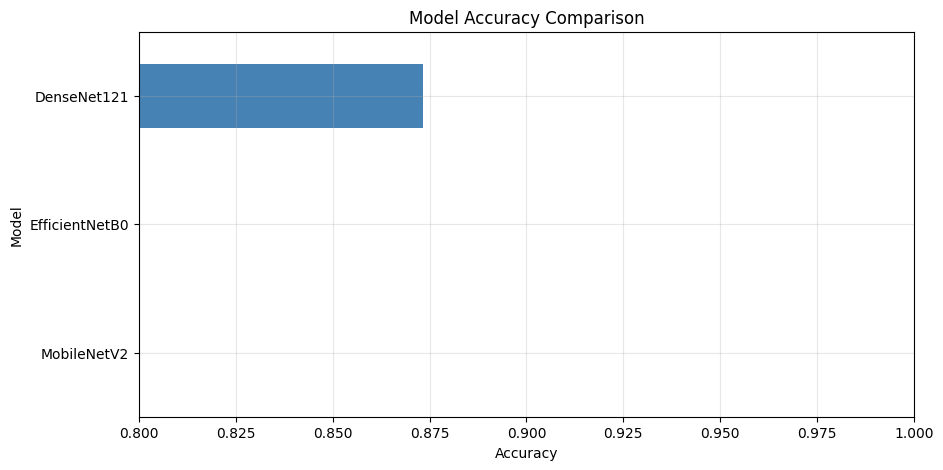

In [43]:
plt.figure(figsize=(10,5))

results_df["Accuracy"].sort_values().plot(
    kind="barh",
    color="steelblue"
)

plt.xlim(0.8, 1.0)

plt.xlabel("Accuracy")

plt.title("Model Accuracy Comparison")

plt.grid(alpha=0.3)

plt.show()

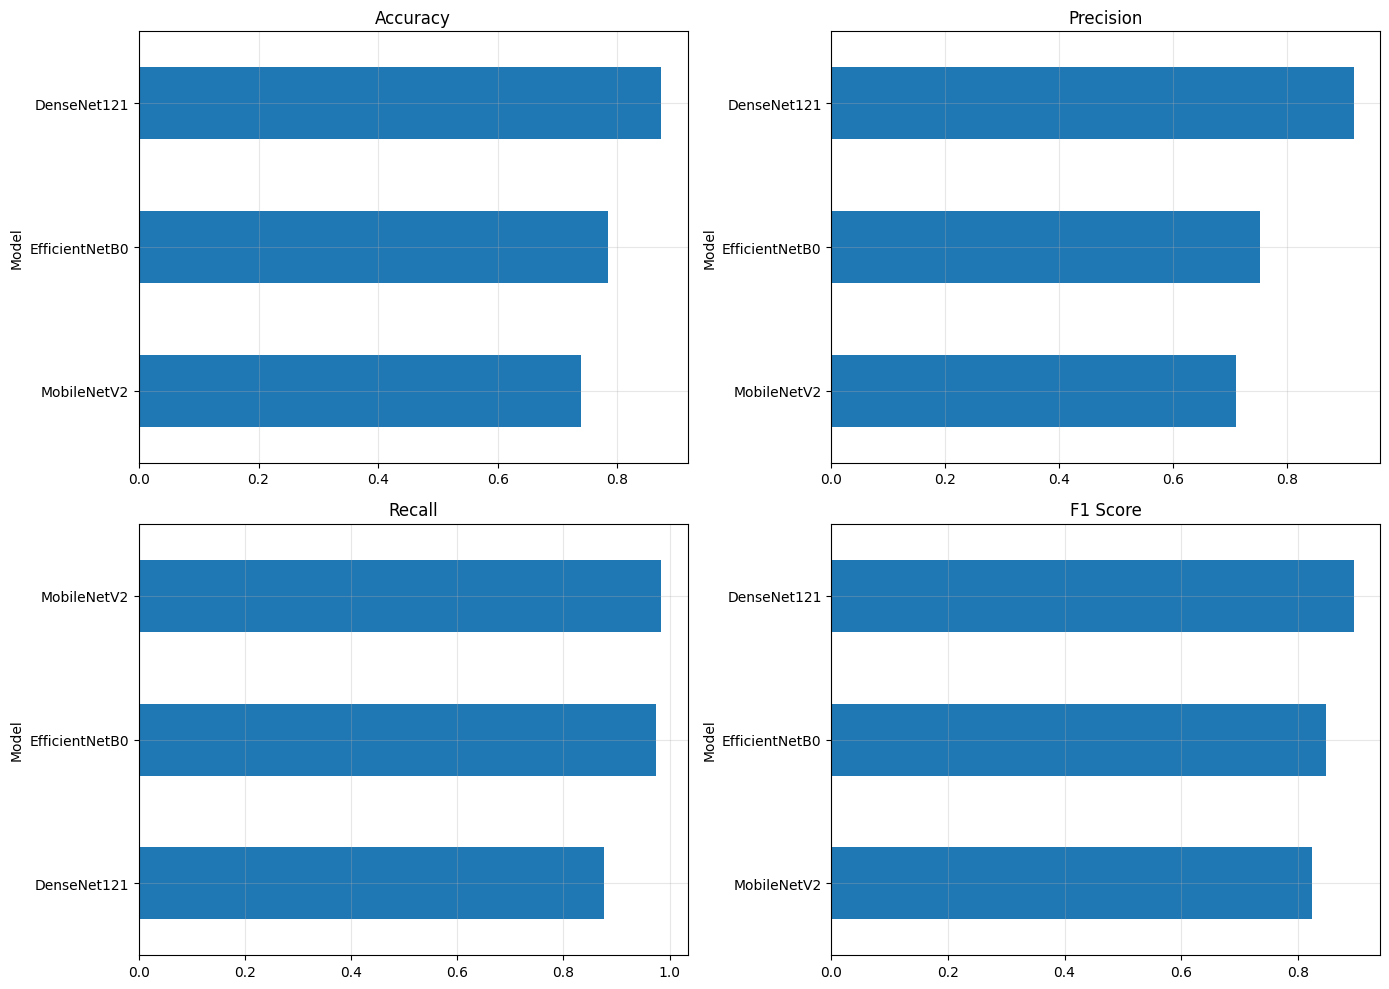

Best Model : DenseNet121


In [44]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

for ax, metric in zip(axes.flatten(), metrics):

    results_df[metric].sort_values().plot(
        kind="barh",
        ax=ax
    )

    ax.set_title(metric)

    ax.grid(alpha=0.3)

plt.tight_layout()

plt.show()

best_model_name = results_df.index[0]

print(f"Best Model : {best_model_name}")

**Model selection criterion:** the best-performing architecture (`best_model_name`)
is chosen by test-set accuracy, but Precision/Recall/F1/AUC above are inspected
together before proceeding to fine-tuning. In a medical screening context, Recall
(catching actual PNEUMONIA cases) matters at least as much as raw Accuracy, since a
false negative here means a missed diagnosis. If the top-accuracy model has a
noticeably lower Recall than a close runner-up, that trade-off is worth flagging
explicitly rather than picking on accuracy alone.

# Fine Tuning

The best-performing model is fine-tuned by unfreezing the final convolutional layers and continuing training with a lower learning rate.

In [45]:
best_model = trained_models[best_model_name]
base_model = backbones[best_model_name]

print(base_model.name)


densenet121


In [46]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

best_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)


**Why the last 30 layers, and why BatchNorm stays frozen:** unfreezing the entire
backbone on a dataset this size risks catastrophic forgetting of the pretrained
ImageNet features. Unfreezing only the last 30 layers lets the network adapt its
higher-level, more task-specific features to chest X-rays while keeping low-level
filters (edges, textures) intact. BatchNorm layers are explicitly re-frozen even
within that unfrozen range, since fine-tuning with a small batch size would otherwise
corrupt their pretrained running mean/variance statistics and destabilize training.

In [47]:
fine_tune_history = best_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=[
        early_stopping,
        reduce_lr
    ]
)


Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 416s 3s/step - accuracy: 0.8984 - auc: 0.9657 - loss: 0.2391 - precision: 0.9655 - recall: 0.8951 - val_accuracy: 0.9061 - val_auc: 0.9828 - val_loss: 0.2201 - val_precision: 0.9829 - val_recall: 0.8892 - learning_rate: 1.0000e-05
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9026 - auc: 0.9692 - loss: 0.2282 - precision: 0.9641 - recall: 0.9016
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
131/131 ━━━━━━━━━━━━━━━━━━━━ 435s 3s/step - accuracy: 0.9034 - auc: 0.9696 - loss: 0.2252 - precision: 0.9677 - recall: 0.9000 - val_accuracy: 0.9090 - val_auc: 0.9838 - val_loss: 0.2031 - val_precision: 0.9844 - val_recall: 0.8918 - learning_rate: 1.0000e-05
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 362s 3s/step - accuracy: 0.9120 - auc: 0.9697 - loss: 0.2232 - precision: 0.9710 - recall: 0.9087 - val_accuracy: 0.9090 - val_auc: 0.9843 - val_loss: 0.2002 - val_precision: 0.9844 - val_recall: 0.8918 - learning_ra

# Final Model Evaluation

The fine-tuned model is evaluated on the unseen test dataset using multiple performance metrics and visual diagnostic plots.

In [48]:
final_metrics, y_true, y_pred, y_prob = evaluate_model(
    best_model,
    test_dataset
)

pd.DataFrame(
    final_metrics,
    index=["DenseNet121 (Fine-Tuned)"]
).T

,DenseNet121 (Fine-Tuned)
Accuracy,0.863782
Precision,0.852194
Recall,0.946154
F1 Score,0.896719
AUC,0.942209


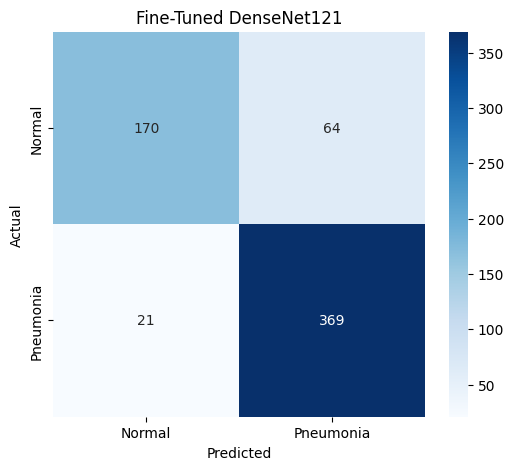

              precision    recall  f1-score   support

           0       0.89      0.73      0.80       234
           1       0.85      0.95      0.90       390

    accuracy                           0.86       624
   macro avg       0.87      0.84      0.85       624
weighted avg       0.87      0.86      0.86       624



In [49]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Pneumonia"],
    yticklabels=["Normal","Pneumonia"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Fine-Tuned DenseNet121")

plt.show()

print(classification_report(y_true, y_pred))

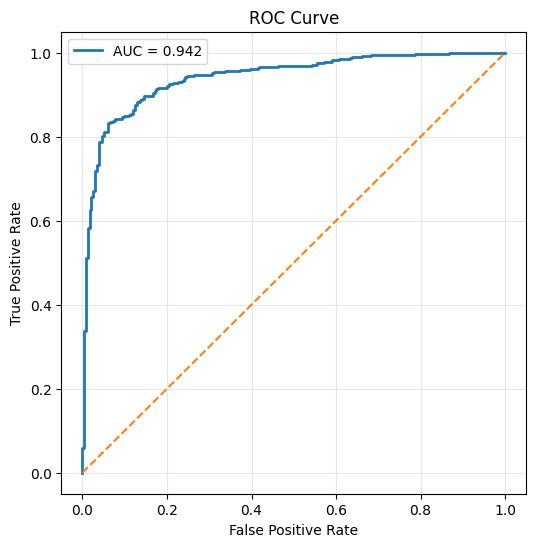

In [50]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {final_metrics['AUC']:.3f}"
)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# Error Analysis

Misclassified test images are inspected directly, and cross-checked against the
image quality signals (blur, brightness, entropy) computed earlier during EDA, to see
whether errors are concentrated in genuinely low-quality scans or reflect a real
model weakness.

In [52]:
CLASS_NAMES = {
    0: "NORMAL",
    1: "PNEUMONIA"
}

In [53]:
test_reset = test_df.reset_index(drop=True)

misclassified_mask = (y_true != y_pred)
misclassified_df = test_reset[misclassified_mask].copy()
misclassified_df["True_Label"] = misclassified_df["Target"].map(CLASS_NAMES)
misclassified_df["Pred_Prob"] = y_prob[misclassified_mask]

quality_rows = []

for path in misclassified_df["Path"]:
    image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    blur = cv2.Laplacian(image, cv2.CV_64F).var()
    quality_rows.append({
        "Brightness": image.mean(),
        "Contrast": image.std(),
        "Blur_Score": blur
    })

misclassified_df = misclassified_df.reset_index(drop=True).join(pd.DataFrame(quality_rows))

print(f"Total misclassified: {len(misclassified_df)} / {len(test_reset)} test images\n")

display(
    misclassified_df[["Label", "True_Label", "Pred_Prob", "Brightness", "Contrast", "Blur_Score"]]
)

print("\nMisclassified image quality vs. full test set average:")
comparison = pd.DataFrame({
    "Misclassified Mean": misclassified_df[["Brightness", "Contrast", "Blur_Score"]].mean(),
    "Test Set Mean": image_stats.loc[image_stats["Dataset"] == "Test", ["Brightness", "Contrast", "Blur_Score"]].mean()
})
display(comparison)


Total misclassified: 85 / 624 test images



,Label,True_Label,Pred_Prob,Brightness,Contrast,Blur_Score
0,NORMAL,NORMAL,0.632906,133.421923,57.957873,105.361389
1,NORMAL,NORMAL,0.628692,136.049440,56.192062,149.933681
2,NORMAL,NORMAL,0.673747,134.133292,62.221604,127.589893
3,NORMAL,NORMAL,0.513681,139.299004,48.148770,158.904191
4,NORMAL,NORMAL,0.508726,151.469691,44.302660,140.125186
...,...,...,...,...,...,...
80,PNEUMONIA,PNEUMONIA,0.392351,132.560345,51.339272,521.466592
81,PNEUMONIA,PNEUMONIA,0.468171,136.422419,53.934333,226.013123
82,PNEUMONIA,PNEUMONIA,0.105006,87.966809,56.835774,76.859649
83,PNEUMONIA,PNEUMONIA,0.216690,94.763307,56.759613,73.128207



Misclassified image quality vs. full test set average:


,Misclassified Mean,Test Set Mean
Brightness,126.091082,121.043637
Contrast,60.163549,57.544772
Blur_Score,118.345808,139.128727


In [54]:
def get_last_conv_layer(model):

    for layer in reversed(model.layers):

        if isinstance(layer, tf.keras.layers.Conv2D):

            return layer.name

    raise ValueError("No Conv2D layer found.")

In [55]:
last_conv_layer = get_last_conv_layer(best_model)

print(last_conv_layer)

grad_model = tf.keras.models.Model(
    inputs=best_model.input,
    outputs=[
        best_model.get_layer(last_conv_layer).output,
        best_model.output
    ]
)

conv5_block16_2_conv


In [56]:
def generate_gradcam(image):

    image = tf.expand_dims(image, axis=0)

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(image)

        loss = predictions[:, 0]

    gradients = tape.gradient(loss, conv_outputs)

    pooled_gradients = tf.reduce_mean(
        gradients,
        axis=(0,1,2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(
        pooled_gradients * conv_outputs,
        axis=-1
    )

    heatmap = tf.maximum(heatmap,0)

    heatmap /= tf.reduce_max(heatmap)+1e-8

    return heatmap.numpy()

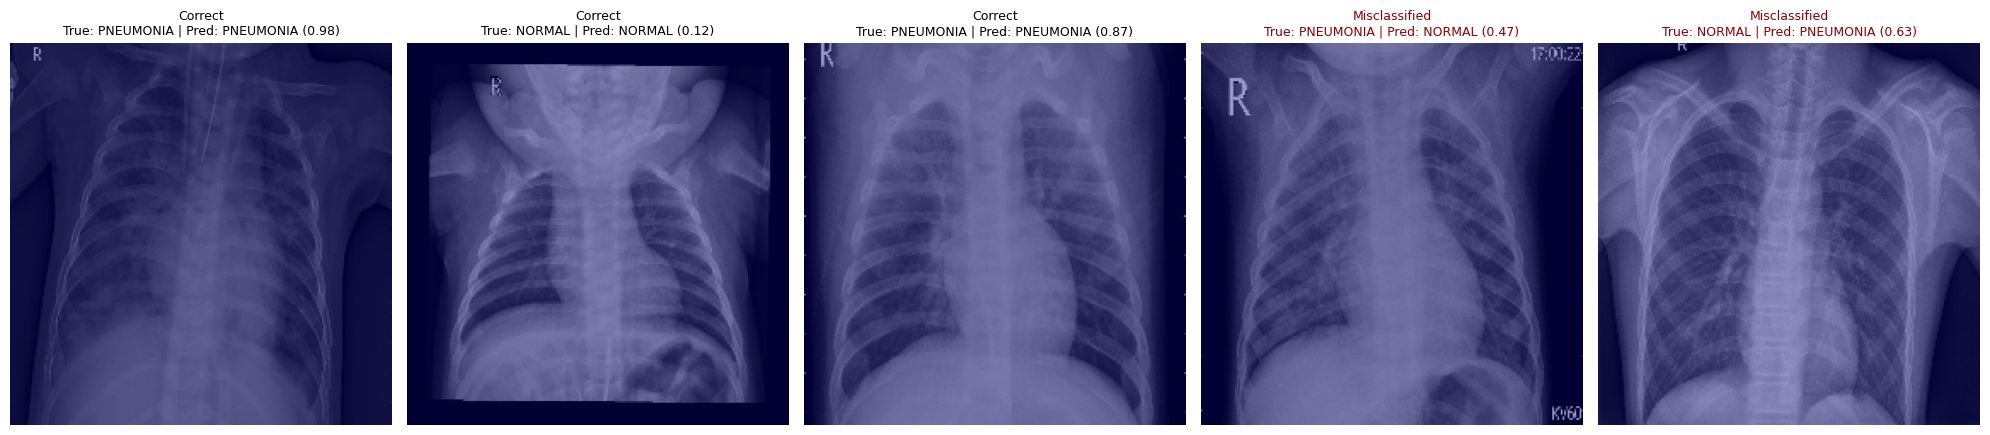

In [57]:
sample_rows = test_df.reset_index(drop=True).copy()
sample_rows["True_Label"] = sample_rows["Target"]
sample_rows["Pred_Label"] = y_pred
sample_rows["Pred_Prob"] = y_prob

correct_samples = sample_rows[sample_rows["True_Label"] == sample_rows["Pred_Label"]].sample(
    3, random_state=SEED
)
wrong_samples = sample_rows[sample_rows["True_Label"] != sample_rows["Pred_Label"]]
wrong_samples = wrong_samples.sample(min(2, len(wrong_samples)), random_state=SEED)

display_samples = pd.concat([correct_samples, wrong_samples])

fig, axes = plt.subplots(1, len(display_samples), figsize=(4 * len(display_samples), 5))

if len(display_samples) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, display_samples.iterrows()):

    raw_image = tf.io.read_file(row["Path"])
    raw_image = tf.image.decode_image(raw_image, channels=3, expand_animations=False)
    raw_image.set_shape([None, None, 3])
    raw_image = tf.image.resize(raw_image, (IMG_SIZE, IMG_SIZE))

    heatmap = generate_gradcam(raw_image)
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET
    )
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    base_image = np.uint8(raw_image.numpy())
    overlay = cv2.addWeighted(base_image, 0.6, heatmap_colored, 0.4, 0)

    correct = row["True_Label"] == row["Pred_Label"]
    tag = "Correct" if correct else "Misclassified"

    ax.imshow(overlay)
    ax.set_title(
        f"{tag}\nTrue: {CLASS_NAMES[row['True_Label']]} | "
        f"Pred: {CLASS_NAMES[row['Pred_Label']]} ({row['Pred_Prob']:.2f})",
        fontsize=9,
        color="darkred" if not correct else "black"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()


# Prediction Pipeline

The trained model is used to predict unseen chest X-ray images by returning the predicted class, confidence score, and class probabilities.

In [58]:
CLASS_NAMES = {
    0: "NORMAL",
    1: "PNEUMONIA"
}

def predict_image(model, image_path):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])

    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    image = tf.cast(image, tf.float32)

    image = tf.expand_dims(image, axis=0)

    probability = model.predict(image, verbose=0)[0][0]

    prediction = int(probability >= 0.5)

    confidence = probability if prediction == 1 else 1 - probability

    return {
        "Prediction": CLASS_NAMES[prediction],
        "Confidence": float(confidence),
        "Probability": float(probability)
    }


In [59]:
sample_path = test_df.sample(1, random_state=42)["Path"].iloc[0]

result = predict_image(
    best_model,
    sample_path
)

print(f"Image       : {sample_path}")
print(f"Prediction  : {result['Prediction']}")
print(f"Confidence  : {result['Confidence']:.2%}")

Image       : ../data/chest_xray\test\PNEUMONIA\person1655_virus_2861.jpeg
Prediction  : PNEUMONIA
Confidence  : 87.46%


In [60]:
best_model.save(f"../models/pneumonia_{best_model_name.lower()}_finetuned.keras")

results_df.to_csv(
    "../models/model_comparison.csv",
    index=True
)

print("Model Saved Successfully")
print("Comparison Table Saved Successfully")

Model Saved Successfully
Comparison Table Saved Successfully


# Conclusion

This project builds an end-to-end pipeline for classifying chest X-rays as **NORMAL**
or **PNEUMONIA**, covering data exploration, quality/leakage checks, model
benchmarking, fine-tuning, and explainability rather than stopping at a single
trained classifier.

**Data handling.** The original dataset's `val` split (16 images) was too small to
serve as a real validation set, so it was pooled with `train` and re-split using a
stratified, leakage-aware approach. The test set was isolated from the start and only
ever touched once, at final evaluation, never for training, validation, or threshold
tuning so the reported metrics reflect genuine generalization rather than a
number that was indirectly tuned against.

**Class imbalance.** PNEUMONIA cases outnumber NORMAL cases in this dataset. Instead
of oversampling or discarding data, `class_weight="balanced"` was used across every
training run (custom CNN, all three transfer-learning backbones, and fine-tuning) so
the loss function penalizes minority-class errors appropriately without distorting
the underlying data distribution.

**Model comparison.** A custom CNN and three pretrained backbones, MobileNetV2,
DenseNet121, and EfficientNetB0 were benchmarked under identical training
conditions. The best-performing backbone (`best_model_name`) was carried forward for
fine-tuning: its last 30 layers were unfrozen at a low learning rate, while
BatchNormalization layers stayed frozen throughout to protect their pretrained
running statistics from being corrupted by fine-tuning on a smaller batch size.

**Evaluation and error analysis.** Beyond accuracy, Precision/Recall/F1/AUC and a
full confusion matrix + ROC curve were used to judge the model Recall in
particular matters here, since a missed PNEUMONIA case (false negative) is far
costlier than a false alarm in a screening context. Misclassified test images were
inspected directly and cross-checked against blur/brightness/contrast signals from
the EDA stage, to distinguish genuine model weaknesses from errors driven by
low-quality scans.

**Explainability.** Grad-CAM was used to visualize which regions of each X-ray
the model actually attended to, on both correctly and incorrectly classified
examples a basic sanity check that the model is learning lung-relevant features
rather than incidental artifacts (borders, text markers, etc.) in the images.

**Limitations.** This dataset does not expose patient-level identifiers, so it's
possible that images from the same patient appear across different splits, a known
limitation of this particular public dataset rather than something fixable from the
code alone. The model is also trained and evaluated on a single source's imaging
equipment/protocol, so performance on X-rays from a different hospital or scanner is
untested and would need external validation before any real-world use.

**Possible extensions:** multi-class classification (bacterial vs. viral pneumonia
vs. normal), calibrating the decision threshold away from the default 0.5 based on
the Recall/Precision trade-off, and testing generalization on an external chest
X-ray dataset